# 7.4 回答第一個 token 在哪個位置被預測？


問題Q，回答A。完整序列是BOS、user、Q、EOS、assistant、A、EOS；要教模型寫第一個A，代價應落在assistant格，因為那格正在猜下一項。

兩字都是ASCII各一byte，Q的ID89、A的ID73。X去掉原序列末項，Y把原序列的下一項答案配到當前輸入格：原序列索引5的A，配到Y索引4，作為X索引4的assistant格所猜的答案；原索引6的EOS則配到Y索引5。也就是把答案配到前一格的預測位置。圖把位置索引、輸入ID和目標ID分欄，先看索引4的assistant→A，再看索引5的A→EOS。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

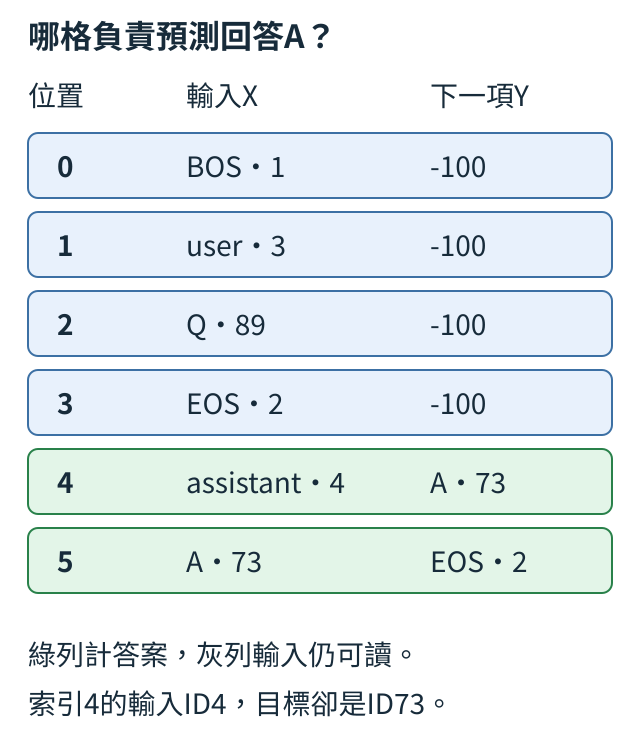

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-07-04-answer-alignment.svg")))

In [3]:
from tiny_perceptron.data import ByteTokenizer, render_chat

tok = ByteTokenizer()
x, y = render_chat(
    [
        {"role": "user", "content": "Q"},
        {"role": "assistant", "content": "A"},
    ]
)
first = (y != -100).nonzero()[0].item()
print("X", x.tolist(), "Y", y.tolist())
print("首答案預測位置", first, "輸入", x[first].item(), "答案", y[first].item())
assert x[first].item() == tok.assistant_id
assert y[first].item() == tok.encode("A")[0]

X [1, 3, 89, 2, 4, 73] Y [-100, -100, -100, -100, 73, 2]
首答案預測位置 4 輸入 4 答案 73


輸入兩消息，Q的ASCII81加8為89，A的65加8為73。輸出X是 `[1,3,89,2,4,73]`，Y是四個-100後接73、2。`nonzero()` 找出條件為True的位置，取第一個得到first=4；該位置X=4，即assistant，而Y=73，即A。下一格X=73則負責預測EOS2。原句索引、當前輸入ID與目標ID，三種數字的用途要分開。

有效目標數對，不保證位置對。mask是哪些目標位置要計代價的標記，也要隨答案配到前一格的預測位置；若還留在原答案所在格，就可能讓首代價落在已讀到A的格。應同時查「X首有效格是assistant、Y是首回答byte」。`render_chat` 已完成這個配對，TinyLM和loss按同一位置比較，不能再移一次。

練習把問題Q改成 `"QQ"`，先預測首答案位置從4變5，但X[first]仍4、Y[first]仍73，再執行核對。接著只把答案A改成B，first仍5、答案ID變74。兩次分別改變前文長度與回答內容，可看清「首目標在哪」取決於哪些材料。

<details>
<summary>補充：實作約定與原始紀錄</summary>

短程式沿用本課工具與原計算語義。安裝、長訓練與重做操作見[訓練配方](https://birdhackor.github.io/tiny-perceptron-vlm/training.html)，不需要先完成長配方才能閱讀這個例子。

</details>
